In [1]:
import pandas as pd
import xarray as xr
from sea_breeze.sea_breeze_funcs import rotate_wind
import matplotlib.pyplot as plt
import datetime as dt
import cartopy.crs as ccrs
from dask.distributed import Client
import numpy as np

In [2]:
client = Client()
client

/g/data/xp65/public/apps/med_conda/envs/analysis3-25.06/lib/python3.11/site-packages/distributed/node.py:187: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 36161 instead
  warnings.warn(


Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: /proxy/36161/status,
Dashboard: /proxy/36161/status,Workers: 7
Total threads: 14,Total memory: 63.00 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:38453,Workers: 0
Dashboard: /proxy/36161/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:42071,Total threads: 2
Dashboard: /proxy/43965/status,Memory: 9.00 GiB
Nanny: tcp://127.0.0.1:36667,


In [23]:
#transect_name = "illawara1"   #South of Sydney, goes through two wind REZs
transect_name = "illawara2"   #Sydney
region = "illawara"
sb_day = pd.read_csv("/g/data/ng72/ab4502/sea_breeze_detection/aus2200_smooth_s4/sb_days/"+region+".csv")
sb_dates = pd.to_datetime(sb_day[sb_day.sb==1]["time"].values)
nonsb_dates = pd.to_datetime(sb_day[sb_day.sb==0]["time"].values)

In [24]:
path = "/g/data/ng72/ab4502/sea_breeze_detection/transects/aus2200/"

ua = xr.open_mfdataset(path+transect_name+"_*_ua.zarr",engine="zarr")
va = xr.open_mfdataset(path+transect_name+"_*_va.zarr",engine="zarr")
wa = xr.open_mfdataset(path+transect_name+"_*_wa.zarr",engine="zarr")
theta = xr.open_mfdataset(path+transect_name+"_*_theta.zarr",engine="zarr")
zmla = xr.open_mfdataset(path+transect_name+"_*_zmla.zarr",engine="zarr")
lsm = xr.open_mfdataset(path+transect_name+"_lsm.zarr",engine="zarr")
orog = xr.open_mfdataset(path+transect_name+"_orog.zarr",engine="zarr")



In [25]:
h=10
ua["time"] = pd.to_datetime(ua["time"]) + dt.timedelta(hours=h)
va["time"] = pd.to_datetime(va["time"]) + dt.timedelta(hours=h)
wa["time"] = pd.to_datetime(wa["time"]) + dt.timedelta(hours=h)
theta["time"] = pd.to_datetime(theta["time"]) + dt.timedelta(hours=h)
zmla["time"] = pd.to_datetime(zmla["time"]) + dt.timedelta(hours=h)

In [26]:
ua_sb = ua.sel(time=np.in1d(ua.time.dt.date,sb_dates.date))
va_sb = va.sel(time=np.in1d(va.time.dt.date,sb_dates.date))
wa_sb = wa.sel(time=np.in1d(wa.time.dt.date,sb_dates.date))
theta_sb = theta.sel(time=np.in1d(theta.time.dt.date,sb_dates.date))
zmla_sb = zmla.sel(time=np.in1d(zmla.time.dt.date,sb_dates.date))

ua_sb_comp = ua_sb.groupby(ua_sb.time.dt.hour).mean().mean("transect").persist()
va_sb_comp = va_sb.groupby(va_sb.time.dt.hour).mean().mean("transect").persist()
wa_sb_comp = wa_sb.groupby(wa_sb.time.dt.hour).mean().mean("transect").persist()
theta_sb_comp = theta_sb.groupby(theta_sb.time.dt.hour).mean().mean("transect").persist()
zmla_sb_comp = zmla_sb.groupby(zmla_sb.time.dt.hour).mean().mean("transect").persist()


In [27]:
ua_nonsb = ua.sel(time=np.in1d(ua.time.dt.date,nonsb_dates.date))
va_nonsb = va.sel(time=np.in1d(va.time.dt.date,nonsb_dates.date))
wa_nonsb = wa.sel(time=np.in1d(wa.time.dt.date,nonsb_dates.date))
theta_nonsb = theta.sel(time=np.in1d(theta.time.dt.date,nonsb_dates.date))
zmla_nonsb = zmla.sel(time=np.in1d(zmla.time.dt.date,nonsb_dates.date))

ua_nonsb_comp = ua_nonsb.groupby(ua_nonsb.time.dt.hour).mean().mean("transect").persist()
va_nonsb_comp = va_nonsb.groupby(va_nonsb.time.dt.hour).mean().mean("transect").persist()
wa_nonsb_comp = wa_nonsb.groupby(wa_nonsb.time.dt.hour).mean().mean("transect").persist()
theta_nonsb_comp = theta_nonsb.groupby(theta_nonsb.time.dt.hour).mean().mean("transect").persist()
zmla_nonsb_comp = zmla_nonsb.groupby(zmla_nonsb.time.dt.hour).mean().mean("transect").persist()


In [28]:
transect_coords = pd.read_csv("/g/data/ng72/ab4502/coastline_data/transect_points/"+transect_name+".csv")

#Extract start and end points
start_lat = transect_coords.start_lat[0]
start_lon = transect_coords.start_lon[0]
end_lat = transect_coords.end_lat[0]
end_lon = transect_coords.end_lon[0]

#Get angle of transect
angle = np.rad2deg((np.arctan2( (end_lat-start_lat) , (end_lon-start_lon) )))

#Angle from N
angle = 90 - angle

#Perpendicular
angle = angle - 90

#Make in range [0,360]
if angle < 0:
    angle = angle+360

In [29]:
#uprime,vprime = rotate_wind(ua.u, va.v, angle)

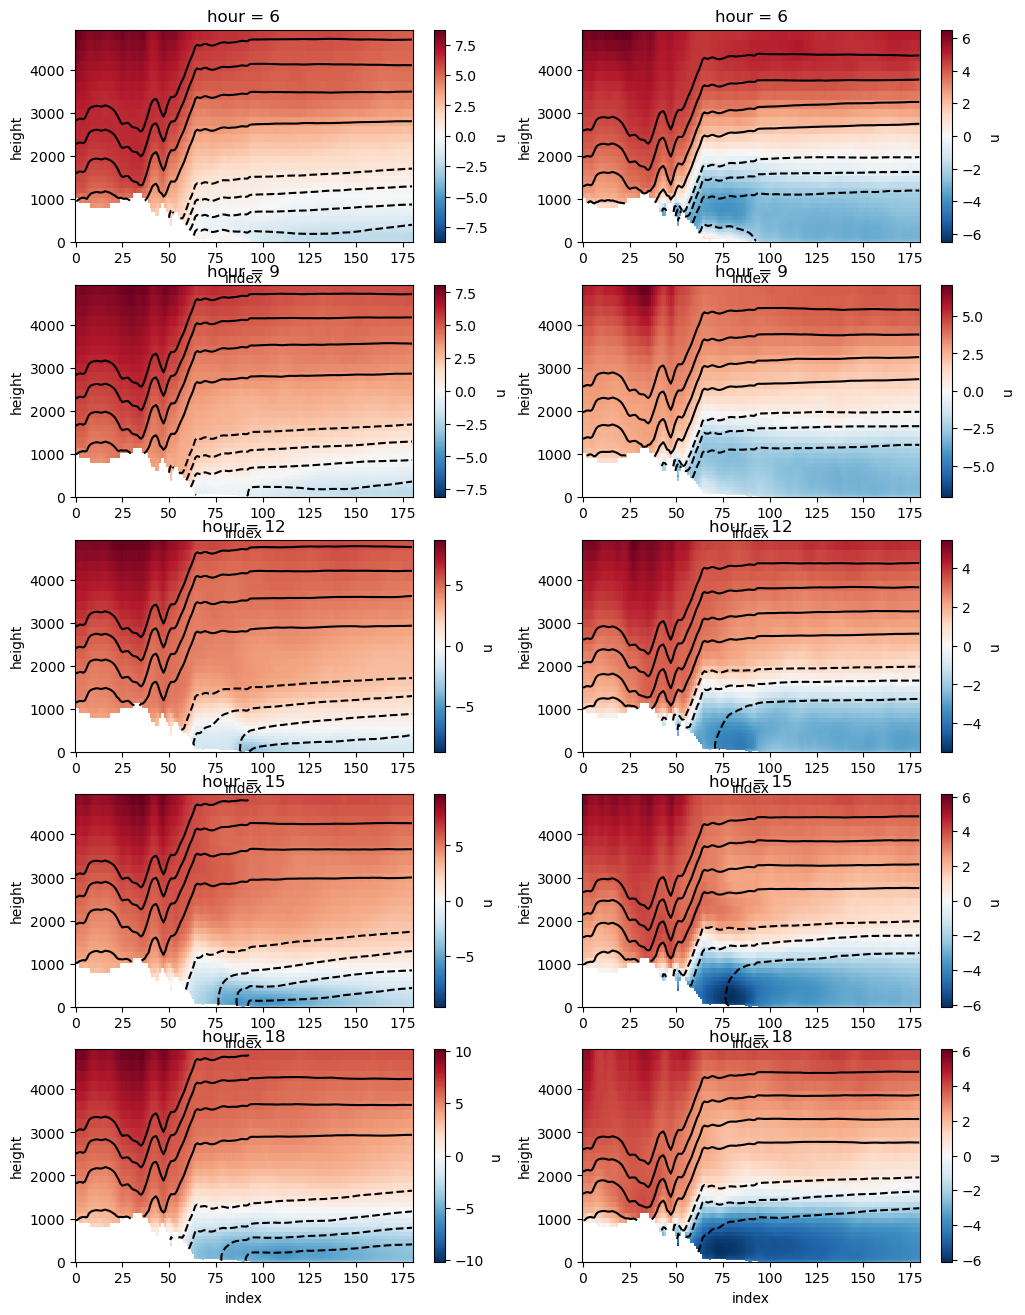

In [30]:
def plot_cs(u,w,theta):

    u.plot(y="height")
    (theta - theta.mean().values).plot.contour(y="height",levels=[-10,-7.5,-5,-2.5,2.5,5,7.5,10],colors="k")



plt.figure(figsize=[12,16])

h=6
plt.subplot(5,2,1)
plot_cs(ua_sb_comp.sel(hour=h).u,None,theta_sb_comp.sel(hour=h).theta)
plt.subplot(5,2,2)
plot_cs(ua_nonsb_comp.sel(hour=h).u,None,theta_nonsb_comp.sel(hour=h).theta)


h=9
plt.subplot(5,2,3)
plot_cs(ua_sb_comp.sel(hour=h).u,None,theta_sb_comp.sel(hour=h).theta)
plt.subplot(5,2,4)
plot_cs(ua_nonsb_comp.sel(hour=h).u,None,theta_nonsb_comp.sel(hour=h).theta)

h=12
plt.subplot(5,2,5)
plot_cs(ua_sb_comp.sel(hour=h).u,None,theta_sb_comp.sel(hour=h).theta)
plt.subplot(5,2,6)
plot_cs(ua_nonsb_comp.sel(hour=h).u,None,theta_nonsb_comp.sel(hour=h).theta)

h=15
plt.subplot(5,2,7)
plot_cs(ua_sb_comp.sel(hour=h).u,None,theta_sb_comp.sel(hour=h).theta)
plt.subplot(5,2,8)
plot_cs(ua_nonsb_comp.sel(hour=h).u,None,theta_nonsb_comp.sel(hour=h).theta)

h=18
plt.subplot(5,2,9)
plot_cs(ua_sb_comp.sel(hour=h).u,None,theta_sb_comp.sel(hour=h).theta)
plt.subplot(5,2,10)
plot_cs(ua_nonsb_comp.sel(hour=h).u,None,theta_nonsb_comp.sel(hour=h).theta)

Text(0.5, 1.0, 'Non SBF days 100 m')

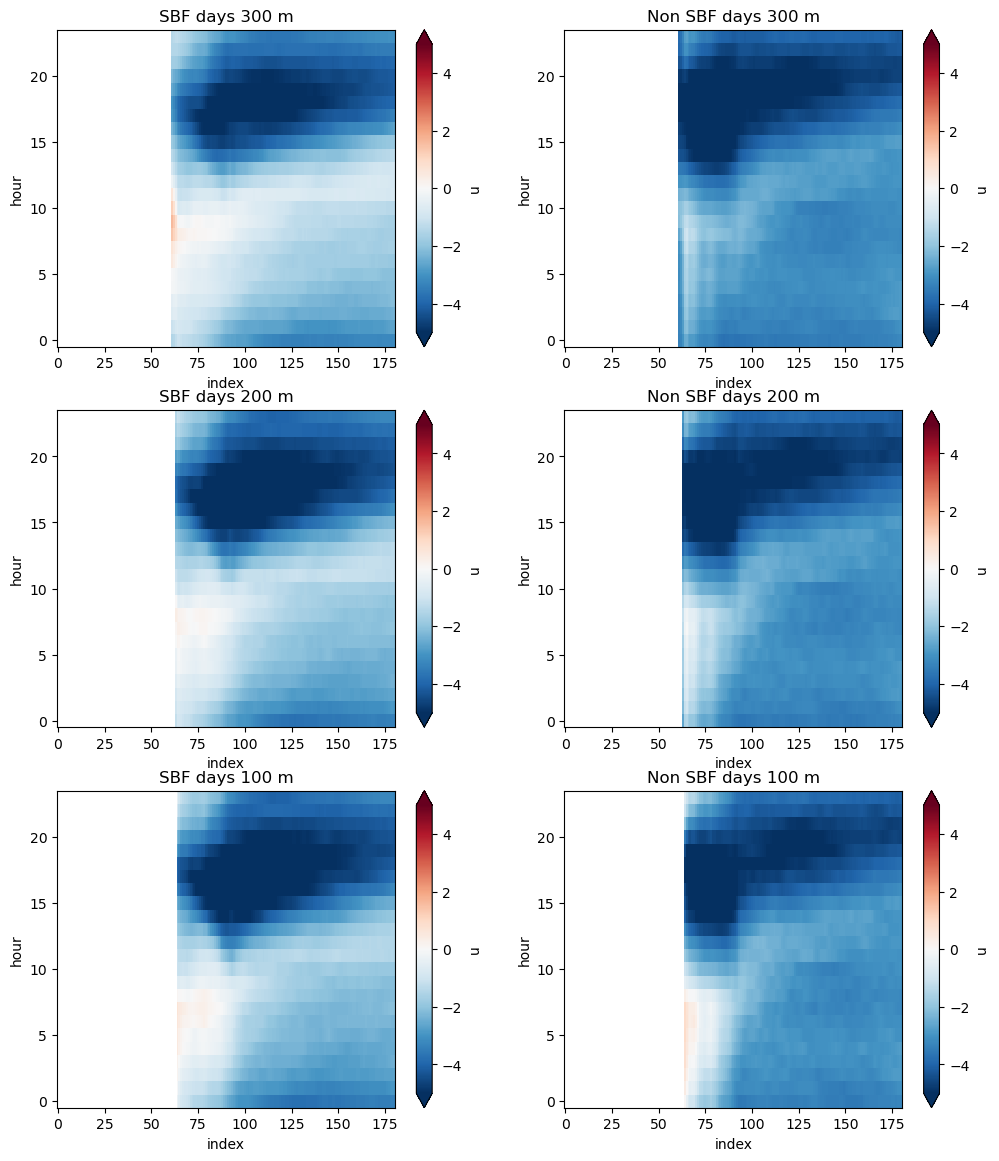

In [31]:
plt.figure(figsize=[12,14])

plt.subplot(3,2,1)
ua_sb_comp.u.sel(height=300,method="nearest").plot(vmin=-5,vmax=5,extend="both",cmap="RdBu_r")
plt.title("SBF days 300 m")

plt.subplot(3,2,2)
ua_nonsb_comp.u.sel(height=300,method="nearest").plot(vmin=-5,vmax=5,extend="both",cmap="RdBu_r")
plt.title("Non SBF days 300 m")

plt.subplot(3,2,3)
ua_sb_comp.u.sel(height=200,method="nearest").plot(vmin=-5,vmax=5,extend="both",cmap="RdBu_r")
plt.title("SBF days 200 m")

plt.subplot(3,2,4)
ua_nonsb_comp.u.sel(height=200,method="nearest").plot(vmin=-5,vmax=5,extend="both",cmap="RdBu_r")
plt.title("Non SBF days 200 m")

plt.subplot(3,2,5)
ua_sb_comp.u.sel(height=100,method="nearest").plot(vmin=-5,vmax=5,extend="both",cmap="RdBu_r")
plt.title("SBF days 100 m")

plt.subplot(3,2,6)
ua_nonsb_comp.u.sel(height=100,method="nearest").plot(vmin=-5,vmax=5,extend="both",cmap="RdBu_r")
plt.title("Non SBF days 100 m")

Text(0.5, 1.0, 'Non SBF days offshore (index=[110,130])')

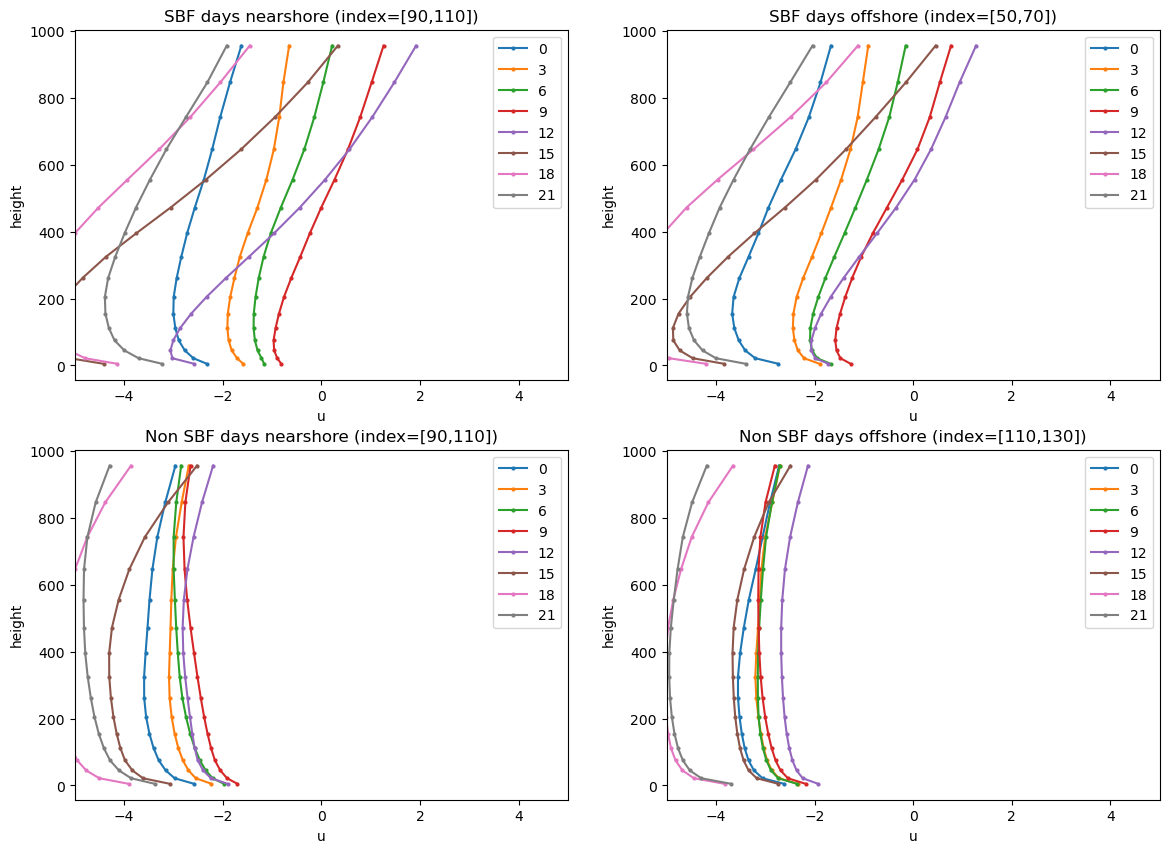

In [32]:
plt.figure(figsize=[14,10])

plt.subplot(2,2,1)    
for h in np.arange(0,24,3):
    #ua_sb_comp.sel(height=slice(0,1000),index=slice(50,70)).mean("index").sel(hour=h).u.plot(y="height",color=plt.get_cmap("twilight_shifted")((h)/24),label=h)
    ua_sb_comp.sel(height=slice(0,1000),index=slice(90,110)).mean("index").sel(hour=h).u.plot(y="height",label=h,ms=2,marker="o")
plt.legend()
plt.xlim([-5,5])
plt.title("SBF days nearshore (index=[90,110])")

plt.subplot(2,2,2)
for h in np.arange(0,24,3):
    #ua_sb_comp.sel(height=slice(0,1000),index=slice(50,70)).mean("index").sel(hour=h).u.plot(y="height",color=plt.get_cmap("twilight_shifted")((h)/24),label=h)
    ua_sb_comp.sel(height=slice(0,1000),index=slice(110,130)).mean("index").sel(hour=h).u.plot(y="height",label=h,ms=2,marker="o")
plt.legend()
plt.xlim([-5,5])
plt.title("SBF days offshore (index=[50,70])")


plt.subplot(2,2,3)    
for h in np.arange(0,24,3):
    #ua_sb_comp.sel(height=slice(0,1000),index=slice(50,70)).mean("index").sel(hour=h).u.plot(y="height",color=plt.get_cmap("twilight_shifted")((h)/24),label=h)
    ua_nonsb_comp.sel(height=slice(0,1000),index=slice(90,110)).mean("index").sel(hour=h).u.plot(y="height",label=h,marker="o",ms=2)
plt.legend()
plt.xlim([-5,5])
plt.title("Non SBF days nearshore (index=[90,110])")

plt.subplot(2,2,4)
for h in np.arange(0,24,3):
    #ua_sb_comp.sel(height=slice(0,1000),index=slice(50,70)).mean("index").sel(hour=h).u.plot(y="height",color=plt.get_cmap("twilight_shifted")((h)/24),label=h)
    ua_nonsb_comp.sel(height=slice(0,1000),index=slice(110,130)).mean("index").sel(hour=h).u.plot(y="height",label=h,ms=2,marker="o")
plt.legend()
plt.xlim([-5,5])
plt.title("Non SBF days offshore (index=[110,130])")
